In [ ]:
import mlflow
# Define o banco de dados na raiz do projeto
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
# Cria ou seleciona um experimento com nome específico
mlflow.set_experiment("Tech-Challenge-Telco-Churn")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             roc_curve, auc)
from mlflow.models.signature import infer_signature
import mlflow
import json
import joblib
import os
import mlflow
import matplotlib.pyplot as plt

In [ ]:
# Carregando o dataset tratado para o repositório
df = pd.read_parquet('../data/processed/dataset_tratado.parquet')

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import os
import json
import joblib
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    roc_curve, auc
)

# -------------------------------
# 1. CONFIGURAÇÕES
# -------------------------------
test_size = 0.2
val_size = 0.1
random_state = 42

TICKET_MEDIO = 65.0
COST_FP = TICKET_MEDIO
COST_FN = TICKET_MEDIO * 5

# -------------------------------
# 2. PREPARAÇÃO DOS DADOS
# -------------------------------
cols_para_remover = ['churn_value', 'churn_reason']
X = df.drop(columns=cols_para_remover)
y = df['churn_value']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_size,
    random_state=random_state, stratify=y_train_val
)

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include='object').columns

preprocessador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

X_train_scaled = preprocessador.fit_transform(X_train)
X_val_scaled = preprocessador.transform(X_val)
X_test_scaled = preprocessador.transform(X_test)

# -------------------------------
# 3. TENSORES
# -------------------------------
def to_tensor(data):
    return torch.tensor(data, dtype=torch.float32)

X_train_t = to_tensor(X_train_scaled)
y_train_t = to_tensor(y_train.values).view(-1, 1)

X_val_t = to_tensor(X_val_scaled)
y_val_t = to_tensor(y_val.values).view(-1, 1)

X_test_t = to_tensor(X_test_scaled)
y_test_t = to_tensor(y_test.values).view(-1, 1)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)

# -------------------------------
# 4. MODELO MLP
# -------------------------------
class ChurnMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train_scaled.shape[1]
model = ChurnMLP(input_dim)

# -------------------------------
# 5. TREINAMENTO
# -------------------------------
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()])

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
patience = 12
best_loss = np.inf
counter = 0

for epoch in range(epochs):
    model.train()

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_X), batch_y)
        loss.backward()
        optimizer.step()

    # validação
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), y_val_t)

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_mlp_model.pt")
    else:
        counter += 1
        if counter >= patience:
            break

# -------------------------------
# 6. INFERÊNCIA (CORRIGIDO)
# -------------------------------
model.load_state_dict(torch.load("best_mlp_model.pt"))
model.eval()

with torch.no_grad():
    logits = model(X_test_t)
    y_probs = torch.sigmoid(logits).numpy().flatten()

threshold = 0.30
y_pred = (y_probs > threshold).astype(int)

# -------------------------------
# 7. MÉTRICAS
# -------------------------------
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

cm = confusion_matrix(y_test, y_pred)

total_cost = (cm[0, 1] * COST_FP) + (cm[1, 0] * COST_FN)

# -------------------------------
# 8. OUTPUTS
# -------------------------------
os.makedirs("outputs/mlp", exist_ok=True)

# Matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=['Fica', 'Churn']).plot(ax=ax)
ax.set_title(f'MLP - Threshold {threshold}')
plt.savefig("outputs/mlp/confusion_matrix.png")
plt.close()

# Classification report
with open("outputs/mlp/classification_report.txt", "w") as f:
    f.write(classification_report(y_test, y_pred))

# Preprocessador
joblib.dump(preprocessador, "outputs/mlp/preprocessador.pkl")

# Features
with open("outputs/mlp/feature_names.json", "w") as f:
    json.dump(list(X_train.columns), f)

# -------------------------------
# 9. RESULTADO FINAL
# -------------------------------
print("-" * 40)
print("✅ MLP FINALIZADA")
print(f"Accuracy: {acc:.4f}")
print(f"Recall: {rec:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Custo Total: R$ {total_cost:.2f}")
print("-" * 40)

----------------------------------------
✅ MLP FINALIZADA
Accuracy: 0.6544
Recall: 0.9305
ROC-AUC: 0.8505
F1-Score: 0.5883
Precision: 0.4302
Custo Total: R$ 38415.00
----------------------------------------


In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

# -------------------------------
# 1. FUNÇÃO DE BOOTSTRAP
# -------------------------------
def bootstrap_ci(y_true, y_pred, y_prob, metric_name, n_bootstrap=500, seed=42):
    np.random.seed(seed)
    n = len(y_true)
    scores = []

    for _ in range(n_bootstrap):
        idx = np.random.choice(range(n), size=n, replace=True)

        if metric_name == "roc_auc":
            # precisa de probabilidade
            if len(np.unique(y_true[idx])) < 2:
                continue
            score = roc_auc_score(y_true[idx], y_prob[idx])
        elif metric_name == "accuracy":
            score = accuracy_score(y_true[idx], y_pred[idx])
        elif metric_name == "recall":
            score = recall_score(y_true[idx], y_pred[idx])

        scores.append(score)

    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)


# -------------------------------
# 2. MÉTRICAS GLOBAIS + IC
# -------------------------------
results = []

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_probs)
}

for metric_name, value in metrics.items():
    ci_lower, ci_upper = bootstrap_ci(
        y_test.values,
        y_pred,
        y_probs,
        metric_name
    )

    results.append({
        "grupo": "global",
        "metrica": metric_name,
        "valor": round(value, 4),
        "ci_lower": round(ci_lower, 4),
        "ci_upper": round(ci_upper, 4)
    })


# -------------------------------
# 3. FUNÇÃO PARA SUBGRUPOS
# -------------------------------
def evaluate_by_group(df, group_col, y_true, y_pred, y_prob):

    rows = []

    for group in df[group_col].dropna().unique():
        mask = df[group_col] == group

        y_t = y_true[mask]
        y_p = y_pred[mask]
        y_pr = y_prob[mask]

        # evitar erro de AUC
        if len(np.unique(y_t)) < 2:
            continue

        metrics = {
            "accuracy": accuracy_score(y_t, y_p),
            "recall": recall_score(y_t, y_p),
            "roc_auc": roc_auc_score(y_t, y_pr)
        }

        for metric_name, value in metrics.items():
            ci_lower, ci_upper = bootstrap_ci(
                y_t.values,
                y_p,
                y_pr,
                metric_name
            )

            rows.append({
                "grupo": f"{group_col}={group}",
                "metrica": metric_name,
                "valor": round(value, 4),
                "ci_lower": round(ci_lower, 4),
                "ci_upper": round(ci_upper, 4)
            })

    return rows


# -------------------------------
# 4. SUBGRUPOS RELEVANTES
# -------------------------------
subgroup_cols = [
    "contract",
    "gender",
    "internet_service"
]

for col in subgroup_cols:
    results.extend(
        evaluate_by_group(X_test.reset_index(drop=True), col,
                          y_test.reset_index(drop=True),
                          y_pred,
                          y_probs)
    )


# -------------------------------
# 5. DATAFRAME FINAL
# -------------------------------
df_resultados = pd.DataFrame(results)

# ordenação opcional
df_resultados = df_resultados.sort_values(by=["grupo", "metrica"])

df_resultados

,grupo,metrica,valor,ci_lower,ci_upper
9,contract=Month-to-month,accuracy,0.5199,0.4858,0.5546
10,contract=Month-to-month,recall,0.9642,0.9414,0.9819
11,contract=Month-to-month,roc_auc,0.7565,0.7222,0.7891
3,contract=One year,accuracy,0.6702,0.6140,0.7176
4,contract=One year,recall,0.8214,0.6667,0.9600
5,contract=One year,roc_auc,0.8220,0.7494,0.8755
6,contract=Two year,accuracy,0.9507,0.9289,0.9739
7,contract=Two year,recall,0.1818,0.0000,0.4842
8,contract=Two year,roc_auc,0.8103,0.7184,0.9068
15,gender=Female,accuracy,0.6443,0.6122,0.6778


In [14]:
import dataframe_image as dfi

dfi.export(
    df_resultados,
    "outputs/tabela_metricas.png",
    table_conversion="matplotlib"  # 🔥 resolve o problema
)

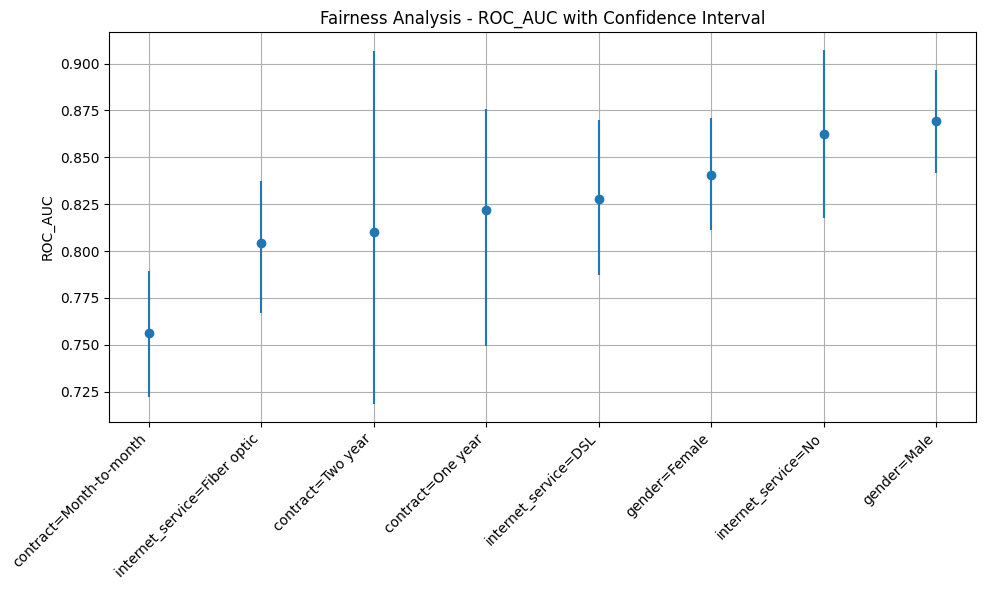

In [10]:
import matplotlib.pyplot as plt

# escolher métrica (pode trocar depois)
metric_to_plot = "roc_auc"

# filtrar dados
df_plot = df_resultados[df_resultados["metrica"] == metric_to_plot].copy()

# remover global se quiser focar só em fairness
df_plot = df_plot[df_plot["grupo"] != "global"]

# ordenar (opcional)
df_plot = df_plot.sort_values("valor")

# labels
labels = df_plot["grupo"]

# valores
values = df_plot["valor"]

# erro (IC)
errors = [
    df_plot["valor"] - df_plot["ci_lower"],
    df_plot["ci_upper"] - df_plot["valor"]
]

# -----------------------
# PLOT
# -----------------------
plt.figure(figsize=(10, 6))

plt.errorbar(
    x=labels,
    y=values,
    yerr=errors,
    fmt='o'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel(metric_to_plot.upper())
plt.title(f"Fairness Analysis - {metric_to_plot.upper()} with Confidence Interval")

plt.grid()

plt.tight_layout()
plt.show()